# Phase 3 — Baselines: the numbers everything else must beat

Phase 2 produced three ways of turning a molecule into numbers and no evidence
that any of them is worth anything. This notebook fits simple scikit-learn
models to all three and settles three questions:

1. Does anything beat the trivial floor of always predicting the mean?
2. Does **geometry** beat plain atom counts?
3. Does the 435-feature sorted Coulomb matrix beat the 29-feature eigenspectrum?

A baseline is not a formality. It makes every later number interpretable, it
catches pipeline bugs that accuracy alone hides, and it is what decides whether
a neural network in Phase 4 has earned its complexity.

*Runtime: about 6 minutes on a laptop CPU — ridge on 435 features dominates.*


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from molecular_property_predictor.baseline import (
    BASELINES,
    evaluate,
    learning_curve,
    load_sweep,
    make_pipeline,
    split_positions,
)
from molecular_property_predictor.data import (
    TARGET_MEAN_BASELINE_MAE_EV,
    TARGET_PROPERTY,
    load_qm9,
)
from molecular_property_predictor.features import load_features

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_qm9()
train_rows, validation_rows, test_rows = split_positions(df, seed=0)
y = df[TARGET_PROPERTY].to_numpy()

print(f"target        : {TARGET_PROPERTY} (eV)")
print(f"train         : {len(train_rows):,}")
print(f"validation    : {len(validation_rows):,}   <- every number below is scored here")
print(f"test          : {len(test_rows):,}   <- untouched, and stays that way")

target        : lumo (eV)
train         : 104,664
validation    : 13,083   <- every number below is scored here
test          : 13,084   <- untouched, and stays that way


## The test set is not opened in this phase

Everything below is scored on **validation**. We are about to make choices by
looking at these numbers — which representation, which model, which
regularisation strength — and every choice made against a set spends some of
that set's ability to estimate performance on unseen data. Compare nine models
on the test set and report the winner, and that number is optimistic by an
amount nobody can measure afterwards.

The consequence is that this project has no headline number yet. That is
correct, not a gap. The test split is opened once, at the end, on one model.

## Scaling lives inside the pipeline, and that is deliberate

Phase 2 emitted raw, unscaled features on purpose. Here is where that is paid
off: the `StandardScaler` sits *inside* the `Pipeline`, so `fit` computes means
and standard deviations from the training rows alone and `predict` applies
those same numbers to validation.

Standardising the whole array up front instead — the obvious shortcut — mixes
validation and test statistics into the training data. Nothing raises, no test
fails, and every reported score comes out quietly better than the truth.
`tests/test_baseline.py` asserts the fitted scaler's mean matches the training
mean and *not* the full-dataset mean, because an assertion is the only thing
that catches this.

In [2]:
results = load_sweep(df, seed=0)

display(
    results.style
    .format({"mae_ev": "{:.4f}", "rmse_ev": "{:.4f}", "r2": "{:.4f}"})
    .background_gradient(subset=["mae_ev"], cmap="RdYlGn_r")
    .set_caption("Validation scores, best first. MAE in eV.")
)

,representation,model,n_features,mae_ev,rmse_ev,r2,params,fit_seconds
0,sorted_coulomb,gradient_boosting,435,0.3692,0.4830,0.8580,-,20.600000
1,eigenspectrum,gradient_boosting,29,0.4636,0.5991,0.7816,-,4.100000
2,sorted_coulomb,ridge,435,0.6320,0.7783,0.6314,alpha=1.0,340.200000
3,eigenspectrum,ridge,29,0.6679,0.8129,0.5978,alpha=0.01,0.800000
4,composition,gradient_boosting,5,0.7488,0.9237,0.4808,-,5.500000
5,composition,ridge,5,0.7686,0.9440,0.4577,alpha=0.01,0.100000
6,eigenspectrum,mean,29,1.0551,1.2819,-0.0000,-,0.100000
7,composition,mean,5,1.0551,1.2819,-0.0000,-,0.000000
8,sorted_coulomb,mean,435,1.0551,1.2819,-0.0000,-,1.200000


## Reading the table

**1. Does anything beat the floor?** Yes, comfortably. Every `mean` row sits at
1.0551 eV with $R^2 \approx 0$ — exactly what predicting a constant should give.
The best model reaches 0.3692 eV, a 65% reduction.

**2. Does geometry beat atom counts?** Yes, and decisively. The best
composition-only model manages 0.7489 eV; the same model on the sorted Coulomb
matrix reaches 0.3692 eV. Roughly half the remaining error disappears when the
model is allowed to see where the atoms are. The five-integer control did its
job: the geometry is genuinely earning its keep, and we now know that rather
than assuming it.

**3. Does 435 beat 29?** Yes — 0.3692 eV against 0.4636 eV. The extra
information in the full sorted matrix is real and usable, despite the
discontinuity demonstrated in Phase 2. That is not obvious in advance, which is
why both were carried forward instead of one being chosen on argument.

A fourth result worth noting: **gradient boosting beats ridge on every
representation.** The relationship between geometry and LUMO energy is not
linear, which is a useful thing to have established with evidence before
reaching for a neural network.

### Two consistency checks

Independent routes to the same numbers, which is what makes them trustworthy.

In [3]:
ridge_composition = results.query(
    "representation == 'composition' and model == 'ridge'"
)["r2"].item()
mean_mae = results.query("model == 'mean'")["mae_ev"].iloc[0]

print("Phase 1 said, from a completely separate OLS fit on the full dataset:")
print(f"  atom counts explain R^2 = 0.4555 of lumo")
print(f"  Phase 3 ridge on composition, validation split:  R^2 = {ridge_composition:.4f}")
print()
print("Phase 1 mean-prediction floor, full dataset:")
print(f"  {TARGET_MEAN_BASELINE_MAE_EV:.4f} eV")
print(f"  Phase 3 mean baseline, validation split:  {mean_mae:.4f} eV")
print(f"  difference: {abs(mean_mae - TARGET_MEAN_BASELINE_MAE_EV):.4f} eV")

Phase 1 said, from a completely separate OLS fit on the full dataset:
  atom counts explain R^2 = 0.4555 of lumo
  Phase 3 ridge on composition, validation split:  R^2 = 0.4577

Phase 1 mean-prediction floor, full dataset:
  1.0510 eV
  Phase 3 mean baseline, validation split:  1.0551 eV
  difference: 0.0041 eV


Both agree. The $R^2$ figures come from different fits on different subsets and
land within 0.002 of each other. The two MAE figures differ by 0.004 eV, which
is the size you would expect from measuring on 13,083 molecules instead of
130,831 — not a discrepancy that needs explaining.

If either check had failed, it would have pointed at a bug in the split or the
features long before any of the model numbers were worth reading. That is the
second job of a baseline.

## The winning model, examined

Aggregate metrics hide the shape of the error. Refitting the best pair and
looking at the predictions directly.

In [4]:
features = load_features(df, "sorted_coulomb")
build, _ = BASELINES["gradient_boosting"]

winner = make_pipeline(build(0))
winner.fit(features[train_rows], y[train_rows])
predicted = winner.predict(features[validation_rows])
actual = y[validation_rows]
error = predicted - actual

print(evaluate(actual, predicted))

{'mae_ev': 0.36921750711392415, 'rmse_ev': 0.4829944644704969, 'r2': 0.8580366087434221}


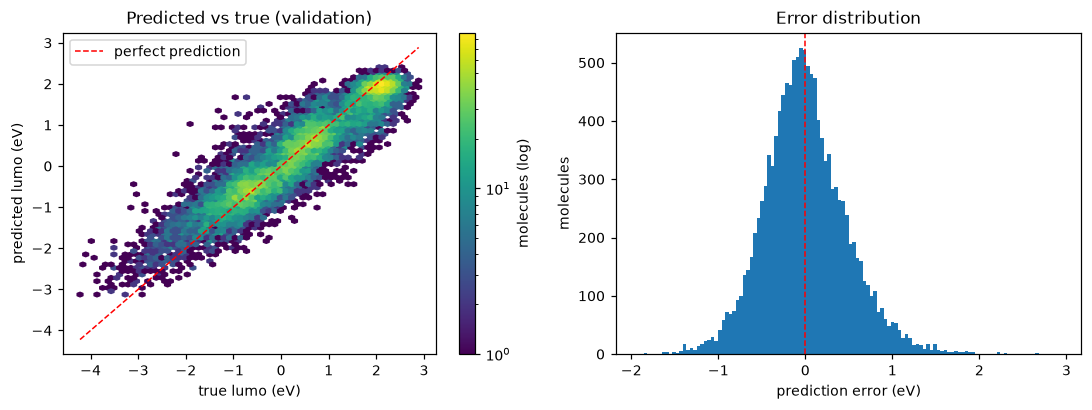

median |error| : 0.2939 eV
within 0.25 eV : 43.5% of molecules
within 0.50 eV : 73.3% of molecules
worst miss     : 2.93 eV
bias (mean err): +0.0002 eV

slope of predicted vs true : 0.811   (1.000 = unbiased at every energy)
MAE, central 90% of molecules: 0.3466 eV
MAE, outer 10%               : 0.5748 eV
mean error, lowest 5% of lumo : +0.6174 eV
mean error, highest 5% of lumo: -0.4994 eV


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

limits = [actual.min(), actual.max()]
hexbin = axes[0].hexbin(actual, predicted, gridsize=60, cmap="viridis", bins="log")
axes[0].plot(limits, limits, "r--", lw=1, label="perfect prediction")
axes[0].set_xlabel(f"true {TARGET_PROPERTY} (eV)")
axes[0].set_ylabel(f"predicted {TARGET_PROPERTY} (eV)")
axes[0].set_title("Predicted vs true (validation)")
axes[0].legend(loc="upper left")
fig.colorbar(hexbin, ax=axes[0], label="molecules (log)")

axes[1].hist(error, bins=120, color="tab:blue")
axes[1].axvline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("prediction error (eV)")
axes[1].set_ylabel("molecules")
axes[1].set_title("Error distribution")

plt.tight_layout()
plt.show()

within = lambda tolerance: 100 * np.mean(np.abs(error) < tolerance)
print(f"median |error| : {np.median(np.abs(error)):.4f} eV")
print(f"within 0.25 eV : {within(0.25):.1f}% of molecules")
print(f"within 0.50 eV : {within(0.50):.1f}% of molecules")
print(f"worst miss     : {np.abs(error).max():.2f} eV")
print(f"bias (mean err): {error.mean():+.4f} eV")

# Is the cloud parallel to the diagonal, or flatter than it?
slope, intercept = np.polyfit(actual, predicted, 1)
low, high = np.percentile(actual, [5, 95])
tails = (actual < low) | (actual > high)
print(f"\nslope of predicted vs true : {slope:.3f}   (1.000 = unbiased at every energy)")
print(f"MAE, central 90% of molecules: {np.abs(error[~tails]).mean():.4f} eV")
print(f"MAE, outer 10%               : {np.abs(error[tails]).mean():.4f} eV")
print(f"mean error, lowest 5% of lumo : {error[actual < low].mean():+.4f} eV")
print(f"mean error, highest 5% of lumo: {error[actual > high].mean():+.4f} eV")

The interesting feature is not the spread but the **slope**. The point cloud is
visibly flatter than the dashed diagonal: at the low end the model predicts
values that are too high, at the high end values that are too low. Overall bias
is essentially zero (+0.0002 eV), but that average conceals two opposite biases
that cancel.

This is **shrinkage towards the mean**, and it is what a squared-error-minimising
model does where evidence is thin. Predicting closer to the centre is the safer
bet when the features do not clearly identify an extreme molecule, so the model
hedges — and the extremes are exactly where it has seen fewest examples. The
tail MAE against central MAE quantifies the same thing.

Note also the gap between MAE (0.369 eV) and RMSE (0.483 eV). That ratio is the
signature of a long tail: most molecules are predicted well, and a minority are
wrong enough to dominate the squared error. This is why both are reported — MAE
alone would hide the tail, RMSE alone would exaggerate it.

Worth carrying into Phase 4: if a neural network improves the aggregate MAE but
leaves this slope unchanged, it has got better at the easy middle and learned
nothing new about the molecules that are actually hard.

## Would more data help?

Worth settling before Phase 4, because it determines where gains can come from.

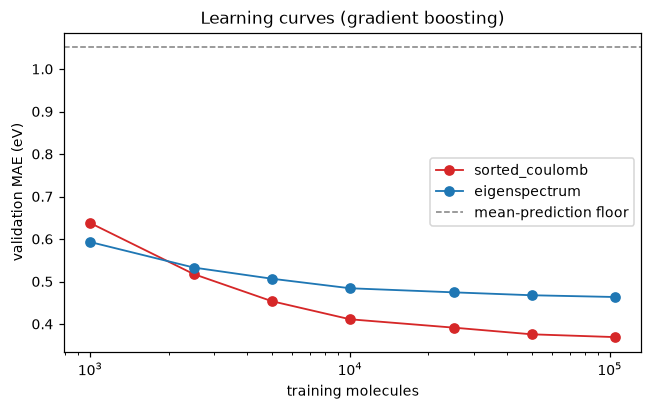

sorted_coulomb  doubling data from 50k to 104,664 buys 0.0066 eV
eigenspectrum   doubling data from 50k to 104,664 buys 0.0041 eV


In [6]:
sizes = [1000, 2500, 5000, 10000, 25000, 50000, len(train_rows)]
curves = {
    kind: learning_curve(df, kind, "gradient_boosting", sizes)
    for kind in ("sorted_coulomb", "eigenspectrum")
}

fig, ax = plt.subplots(figsize=(6, 3.8))
for (kind, curve), colour in zip(curves.items(), ["tab:red", "tab:blue"]):
    ax.plot(curve["n_train"], curve["mae_ev"], "o-", color=colour, label=kind, lw=1.2)
ax.axhline(TARGET_MEAN_BASELINE_MAE_EV, color="grey", ls="--", lw=1,
           label="mean-prediction floor")
ax.set_xscale("log")
ax.set_xlabel("training molecules")
ax.set_ylabel("validation MAE (eV)")
ax.set_title("Learning curves (gradient boosting)")
ax.legend()
plt.tight_layout()
plt.show()

for kind, curve in curves.items():
    last_two = curve.tail(2)["mae_ev"].to_numpy()
    print(f"{kind:<15} doubling data from 50k to {len(train_rows):,} buys "
          f"{last_two[0] - last_two[1]:.4f} eV")

Both curves have flattened. Doubling the training data from 50,000 to 104,664
molecules buys 0.007 eV on the sorted Coulomb matrix and 0.004 eV on the
eigenspectrum — a rounding error against a 0.37 eV MAE.

**So more data is not the bottleneck.** Whatever Phase 4 gains will come from
the model or the representation, not from finding more molecules. That is a
genuinely useful thing to know before building a network, and it costs seven
fits to find out.

There is a second result hiding in this plot. At 1,000 training molecules the
**29-feature eigenspectrum beats the 435-feature sorted matrix** (0.593 eV
against 0.638 eV), and the ranking reverses somewhere between 1,000 and 2,500.
The richer representation carries more information but needs more examples
before a model can exploit it. Choosing a representation on a small pilot run
would have picked the wrong one.

## Where 0.369 eV actually sits

Honestly: not close to the state of the art. Published models on QM9 predict
LUMO to roughly 0.02–0.04 eV — about an order of magnitude better than this.

That gap is expected and is not a defect in the pipeline. It is the price of a
2012 representation and an off-the-shelf regressor. Modern results come from
message-passing graph neural networks that learn the representation and the
model together, rather than fixing the features in advance as we have here.

What this phase does establish, which is what it was for:

- The pipeline is sound end to end — two independent consistency checks pass.
- Geometry beats composition, so the representation is doing real work.
- The problem is non-linear, so a neural network is a reasonable next step
  rather than a fashionable one.
- More data will not help; the model is the ceiling.

## The bar for Phase 4

| | MAE (eV) | R² |
|---|---|---|
| Always predict the mean | 1.0551 | 0.000 |
| Ridge, sorted Coulomb | 0.6320 | 0.631 |
| **Gradient boosting, sorted Coulomb** | **0.3692** | **0.858** |

Phase 4's PyTorch network has to beat **0.3692 eV** on the same seeded split to
have earned its place. If it does not, that gets reported as plainly as if it
had.